# 05 - Modelos de clasificación

Entrenamos cinco modelos en orden de complejidad creciente y comparamos
su performance usando MLflow para tracking de experimentos.

Los modelos evaluados son:
- Regresión Logística (baseline)
- Random Forest
- XGBoost
- LightGBM
- SVM

## 1. Carga de datos procesados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow
import mlflow.sklearn
import joblib

X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (18101, 4)
X_test:  (4526, 4)
y_train: (18101,)
y_test:  (4526,)


## 2. Configuración de MLflow

MLflow registra cada experimento automáticamente: parámetros,
métricas y modelos. Permite comparar todos los modelos en una
UI visual en lugar de comparar prints manualmente.

In [12]:
import mlflow
from mlflow.tracking import MlflowClient

# Crear experimento si no existe
client = MlflowClient()
experiment = client.get_experiment_by_name("asteroid-hazard-classifier")
if experiment is None:
    experiment_id = client.create_experiment("asteroid-hazard-classifier")
else:
    experiment_id = experiment.experiment_id

def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    with mlflow.start_run(run_name=nombre, experiment_id=experiment_id):
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        
        reporte = classification_report(y_test, y_pred,
                                       target_names=['No peligroso', 'Peligroso'],
                                       output_dict=True)
        
        mlflow.log_param("modelo", nombre)
        mlflow.log_metric("precision_peligroso", reporte['Peligroso']['precision'])
        mlflow.log_metric("recall_peligroso", reporte['Peligroso']['recall'])
        mlflow.log_metric("f1_peligroso", reporte['Peligroso']['f1-score'])
        mlflow.log_metric("f1_macro", reporte['macro avg']['f1-score'])
        mlflow.sklearn.log_model(modelo, nombre)
        
        print(f"\n=== {nombre} ===")
        print(classification_report(y_test, y_pred,
                                    target_names=['No peligroso', 'Peligroso']))
    return y_pred

print(f"Experimento ID: {experiment_id}")

Experimento ID: 1


## 3. Entrenamiento y evaluación de modelos

In [13]:
scale_pos_weight = y_train.value_counts()[False] / y_train.value_counts()[True]

modelos = {
    "Regresion Logistica": LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', random_state=42, n_estimators=100
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        class_weight='balanced', random_state=42, verbose=-1
    ),
    "SVM": SVC(
        class_weight='balanced', random_state=42, probability=True
    )
}

resultados = {}
for nombre, modelo in modelos.items():
    y_pred = evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test)
    resultados[nombre] = y_pred

2026/04/24 19:38:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 19:38:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Regresion Logistica ===
              precision    recall  f1-score   support

No peligroso       1.00      0.87      0.93      4274
   Peligroso       0.30      0.98      0.46       252

    accuracy                           0.87      4526
   macro avg       0.65      0.92      0.69      4526
weighted avg       0.96      0.87      0.90      4526



2026/04/24 19:38:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 19:38:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Random Forest ===
              precision    recall  f1-score   support

No peligroso       0.96      0.99      0.98      4274
   Peligroso       0.67      0.37      0.47       252

    accuracy                           0.95      4526
   macro avg       0.82      0.68      0.72      4526
weighted avg       0.95      0.95      0.95      4526



2026/04/24 19:38:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 19:38:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== XGBoost ===
              precision    recall  f1-score   support

No peligroso       0.98      0.93      0.96      4274
   Peligroso       0.40      0.76      0.53       252

    accuracy                           0.92      4526
   macro avg       0.69      0.85      0.74      4526
weighted avg       0.95      0.92      0.93      4526



2026/04/24 19:38:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 19:38:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== LightGBM ===
              precision    recall  f1-score   support

No peligroso       0.99      0.91      0.95      4274
   Peligroso       0.37      0.90      0.53       252

    accuracy                           0.91      4526
   macro avg       0.68      0.91      0.74      4526
weighted avg       0.96      0.91      0.93      4526



2026/04/24 19:39:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 19:39:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== SVM ===
              precision    recall  f1-score   support

No peligroso       1.00      0.86      0.93      4274
   Peligroso       0.30      1.00      0.46       252

    accuracy                           0.87      4526
   macro avg       0.65      0.93      0.69      4526
weighted avg       0.96      0.87      0.90      4526



## 4. Comparativa de modelos

In [14]:
from sklearn.metrics import f1_score, precision_score, recall_score

resumen = []
for nombre, y_pred in resultados.items():
    resumen.append({
        'Modelo': nombre,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Peligroso': f1_score(y_test, y_pred),
        'F1 Macro': f1_score(y_test, y_pred, average='macro')
    })

df_resultados = pd.DataFrame(resumen)
df_resultados = df_resultados.sort_values('F1 Macro', ascending=False)
print(df_resultados.round(3).to_string(index=False))

             Modelo  Precision  Recall  F1 Peligroso  F1 Macro
            XGBoost      0.405   0.758         0.528     0.743
           LightGBM      0.371   0.905         0.527     0.738
      Random Forest      0.667   0.365         0.472     0.724
Regresion Logistica      0.300   0.976         0.459     0.693
                SVM      0.299   0.996         0.460     0.693


In [15]:
import mlflow

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())

# Listar todos los experimentos
client = mlflow.tracking.MlflowClient()
experiments = client.search_experiments()
for exp in experiments:
    print(f"\nExperimento: {exp.name} (ID: {exp.experiment_id})")
    runs = client.search_runs(exp.experiment_id)
    print(f"Runs: {len(runs)}")
    for run in runs:
        print(f"  - {run.info.run_name}: {run.data.metrics}")
        

MLflow version: 3.11.1
Tracking URI: sqlite:////Users/helgazambrana/Desktop/HELGA/TRABAJO/PROYECTOS/asteroid-classifier/notebooks/mlflow.db

Experimento: asteroid-hazard-classifier (ID: 1)
Runs: 10
  - SVM: {'precision_peligroso': 0.2988095238095238, 'recall_peligroso': 0.996031746031746, 'f1_peligroso': 0.4597069597069597, 'f1_macro': 0.6927931783459421}
  - LightGBM: {'precision_peligroso': 0.3713355048859935, 'recall_peligroso': 0.9047619047619048, 'f1_peligroso': 0.5265588914549654, 'f1_macro': 0.738236689802733}
  - XGBoost: {'precision_peligroso': 0.4046610169491525, 'recall_peligroso': 0.7579365079365079, 'f1_peligroso': 0.5276243093922652, 'f1_macro': 0.743279013485758}
  - Random Forest: {'precision_peligroso': 0.6666666666666666, 'recall_peligroso': 0.36507936507936506, 'f1_peligroso': 0.4717948717948718, 'f1_macro': 0.7240064176568448}
  - Regresion Logistica: {'precision_peligroso': 0.3, 'recall_peligroso': 0.9761904761904762, 'f1_peligroso': 0.458955223880597, 'f1_macro': 

## 5. Matriz de confusión — XGBoost

XGBoost fue seleccionado como modelo principal por tener el mejor
F1 Macro (0.743). Visualizamos exactamente dónde acierta y dónde falla.

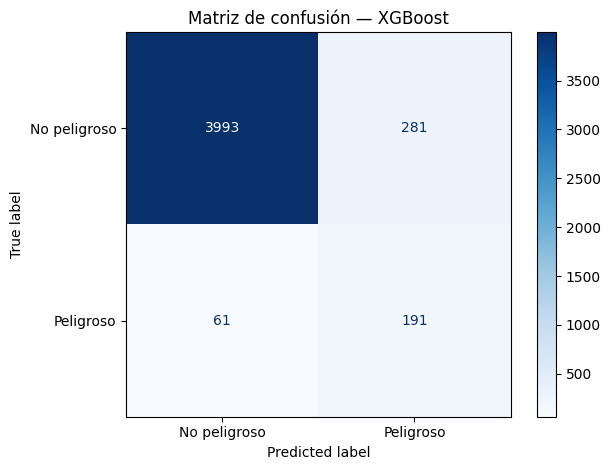

In [16]:
cm = confusion_matrix(y_test, resultados['XGBoost'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No peligroso', 'Peligroso'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — XGBoost')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning — XGBoost

Hasta ahora usamos XGBoost con parámetros por defecto. El tuning
busca la combinación de parámetros que maximiza el F1 Macro.

Usamos GridSearchCV que prueba todas las combinaciones posibles
y usa cross-validation para evaluar cada una (no dependemos
de un solo split train/test).

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [scale_pos_weight]
}

xgb_tuning = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    xgb_tuning,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_search.best_params_)
print(f"\nMejor F1 Macro en cross-validation: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros:
{'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': np.float64(16.93954410307235)}

Mejor F1 Macro en cross-validation: 0.7418


## 7. Evaluación del modelo tuneado

In [19]:
xgb_final = XGBClassifier(
    learning_rate=0.3,
    max_depth=7,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_final.fit(X_train, y_train)
y_pred_final = xgb_final.predict(X_test)

print("XGBoost Tuneado")
print(classification_report(y_test, y_pred_final,
                            target_names=['No peligroso', 'Peligroso']))

XGBoost Tuneado
              precision    recall  f1-score   support

No peligroso       0.98      0.94      0.96      4274
   Peligroso       0.41      0.67      0.51       252

    accuracy                           0.93      4526
   macro avg       0.69      0.81      0.73      4526
weighted avg       0.95      0.93      0.94      4526



In [20]:
import joblib
joblib.dump(modelos['XGBoost'], '../data/xgboost_final.pkl')
print("Modelo guardado en data/xgboost_final.pkl")

Modelo guardado en data/xgboost_final.pkl
